第15章

In [1]:
import pandas as pd
df=pd.read_csv('..\sukkiri-ml2-codes\datafiles\Wholesale.csv')
display(df.head(3))

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844


In [2]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [3]:
df=df.drop(['Channel','Region'],axis=1)  #学習のために今回はややこしい列を削除


In [4]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc_df=sc.fit_transform(df)
sc_df=pd.DataFrame(sc_df,columns=df.columns)

In [5]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3,random_state=0)
model.fit(sc_df)
model.labels_

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 1, 0, 2, 2, 2, 1, 0, 2, 2, 2, 0, 2, 2, 0, 2, 1, 0, 0, 2, 2, 1,
       2, 1, 1, 1, 2, 1, 2, 2, 0, 2, 0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 0, 0, 2, 0, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 0,
       2, 0, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1,
       2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2,
       0, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 1, 1, 0, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 1, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 0, 0, 0, 0,
       2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [6]:
sc_df['cluster']=model.labels_
sc_df.head(3)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339,2
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151,2
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293,2


In [7]:
sc_df.groupby('cluster').mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,1.523225,-0.136629,-0.245823,1.038595,-0.409281,0.305114
1,-0.242638,1.943918,2.138295,-0.042127,2.076593,0.646200
2,-0.305934,-0.247152,-0.250504,-0.226214,-0.205140,-0.160539


<Axes: xlabel='cluster'>

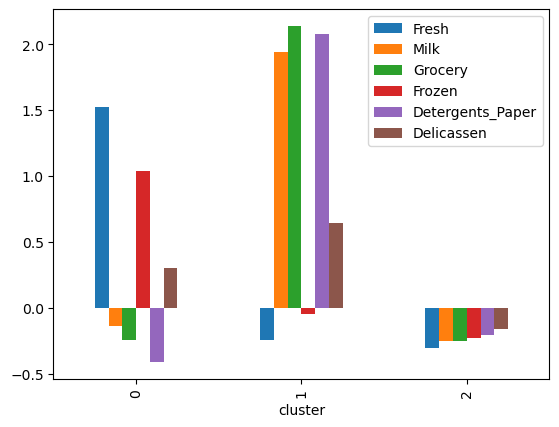

In [8]:
cluster_mean=sc_df.groupby('cluster').mean()
cluster_mean.plot(kind='bar')

In [9]:
sse_list=[]
for n in range(2,31):
    model=KMeans(n_clusters=n,random_state=0)
    model.fit(sc_df)
    sse=model.inertia_
    sse_list.append(sse)
print(sse_list)

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[2184.1520787874542, 1650.770187770802, 1358.6826733312398, 1084.98807719229, 976.7895922045105, 873.0879648315713, 819.2521461941692, 718.6803804619203, 673.6791943459298, 633.9487005583328, 614.0405938226071, 555.1324949163234, 527.8900171008177, 476.3316236148393, 440.47081977529587, 420.2362471705121, 399.85121407845486, 388.6095198127215, 359.93689445935956, 337.7321758899185, 308.52814956813336, 292.64883855546543, 282.826623775877, 272.4244531336815, 262.87268751542445, 270.6723720639327, 255.73187196988002, 237.71231575184254, 230.80420448010835]


<Axes: >

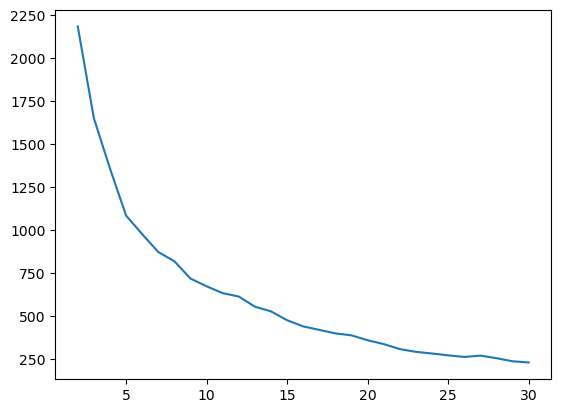

In [11]:
se=pd.Series(sse_list)
num=range(2,31)
se.index=num
se.plot(kind='line')

In [13]:
model=KMeans(n_clusters=5,random_state=0)
model.fit(sc_df)
sc_df['cluster']=model.labels_
sc_df.to_csv('clustered_Wholesale.csv,index=False')

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
